In [1]:
from graphviz import Digraph

In [ ]:
class Expression:
    def __init__(self, value: float):
        self.value = value
        self.grad = 0.0
        self.operands = []
        self.op = 'op'
        self.backward = lambda: None
    def __add__(self, other):
        result = Expression(self.value + other.value)
        result.op = '+'
        def backward():
            self.grad += result.grad
            other.grad += result.grad                        
        result.backward = backward
        result.operands = [self, other]
        return result

    def __mul__(self, other):
        result = Expression(self.value * other.value)
        result.op = '*'
        def backward():
            self.grad += other.value * result.grad
            other.grad += self.value * result.grad            
        result.backward = backward
        result.operands = [self, other]
        return result

def backward(root : Expression):
    result = []
    def tsort(e: Expression):
        if e not in result:
            result.append(e)
            for o in e.operands:
                tsort(o)
    tsort(root)
    for e in result:
        e.grad = 0.0
    root.grad = 1
    for e in result:
        e.backward()
    

In [6]:
def trace(e: Expression):
    nodes, edges = set(), set()
    def build(v: Expression):
        if v not in nodes:
            nodes.add(v)
            for o in v.operands:
                edges.add((o, v))
                build(o)
    build(e)
    return nodes, edges

def draw_dot(root: Expression, format='svg', rankdir = 'LR'):
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})
    for n in nodes:
        dot.node(name=str(id(n)), label="{value%.4f | grad%.4f}" % (n.value, n.grad), shape='record')
        if n.op:
            dot.node(name=str(id(n)) + n.op, label=n.op)
            dot.edge(str(id(n)) + n.op, str(id(n)))
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2.op)
    return dot

+++
***


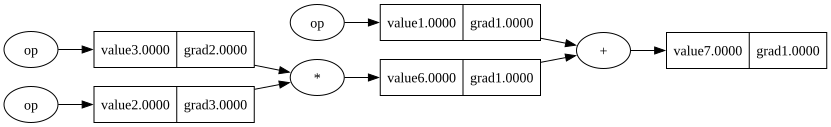

In [18]:
a = Expression(1)
b = Expression(2)
c = Expression(3)
d = a + b * c
backward(d)
draw_dot(d)